# 1. Base Setup

## 1.1 Install packages

In [1]:
!pip install kagglehub

## 1.2 Load all needed imports

In [2]:
from pathlib import Path

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import matplotlib.pyplot as plt

from dateutil.relativedelta import relativedelta

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, log_loss, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, GridSearchCV

from scipy.stats import randint


/Users/anton/.pyenv/versions/3.10.6/envs/cf_copilot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Load the data

In [3]:
def load_cashflow_data(csv_name: str = "dataset.csv") -> pd.DataFrame:
    # 1) Look for local file first: ../raw_data/dataset.csv
    base_dir = Path.cwd().parent          # one level up from notebook
    raw_data_dir = base_dir / "raw_data"
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    local_path = raw_data_dir / csv_name

    if local_path.is_file():
        print(f"Loading local file: {local_path}")
        return pd.read_csv(local_path)

    # 2) If not found, download from Kaggle once via kagglehub
    print("Local file not found, downloading from Kaggle via kagglehub...")
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "pradumn203/payment-date-prediction-for-invoices-dataset",
        "dataset.csv",  # main CSV name on Kaggle
    )

    # Save for future offline use
    df.to_csv(local_path, index=False)
    print(f"Saved local copy to {local_path}")

    return df

df = load_cashflow_data()

Loading local file: /Users/anton/code/DERNTOAN/cf_copilot/raw_data/dataset.csv


# 3. EDA

## 3.1 General Informatoin

In [4]:
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1.929874e+09,2019-09-14,20190914,20190914,20190929.0,USD,RV,1.0,NaN,2253.86,20190914.0,NAA8,1.929874e+09,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2.960623e+09,2020-03-30,20200330,20200330,20200410.0,CAD,RV,1.0,NaN,3299.70,20200331.0,CA10,2.960623e+09,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1.930148e+09,2019-11-13,20191113,20191113,20191128.0,USD,RV,1.0,NaN,33133.29,20191113.0,NAH4,1.930148e+09,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           50000 non-null  object 
 1   cust_number             50000 non-null  object 
 2   name_customer           50000 non-null  object 
 3   clear_date              40000 non-null  object 
 4   buisness_year           50000 non-null  float64
 5   doc_id                  50000 non-null  float64
 6   posting_date            50000 non-null  object 
 7   document_create_date    50000 non-null  int64  
 8   document_create_date.1  50000 non-null  int64  
 9   due_in_date             50000 non-null  float64
 10  invoice_currency        50000 non-null  object 
 11  document type           50000 non-null  object 
 12  posting_id              50000 non-null  float64
 13  area_business           0 non-null      float64
 14  total_open_amount       50000 non-null

# 4. Data Cleaning

In [6]:
def data_cleaning(df):
    """Clean the data and create csvs."""

    # 1. Drop duplicate rows
    df = df.drop_duplicates()

    # 2. strip column names, and standardize the cases
    df.columns = df.columns.str.strip()

    # 3. Drop invalid invoice ids rows
    df = df.dropna(subset=["invoice_id"]).copy()
    df["invoice_id"] = pd.to_numeric(df["invoice_id"], errors="coerce")
    # 3.1 even if failed to parse,just drop them
    df = df[df["invoice_id"].notna()].copy()

    # 4. fixing date formats
    def parse_yyyymmdd_float(s):
        return pd.to_datetime(
            pd.to_numeric(s, errors="coerce").astype("Int64").astype("string"),
            format="%Y%m%d",
            errors="coerce",
        )

    df["clear_date"] = pd.to_datetime(df["clear_date"], errors="coerce")
    df["buisness_year"] = df["buisness_year"].astype("int64")
    df["posting_date"] = pd.to_datetime(df["posting_date"], errors="coerce")
    df["document_create_date"] = pd.to_datetime(df["document_create_date"], errors="coerce")
    df["document_create_date.1"] = pd.to_datetime(df["document_create_date.1"], errors="coerce")
    df["due_in_date"] = parse_yyyymmdd_float(df["due_in_date"])
    df["baseline_create_date"] = parse_yyyymmdd_float(df["baseline_create_date"])

    # 5. Now cast IDs
    df["doc_id"] = df["doc_id"].astype("int64")
    df["invoice_id"] = df["invoice_id"].astype("int64")

    # 6. standardize cat_cols
    cat_cols = ["business_code", "invoice_currency", "cust_payment_terms",\
        "name_customer"]
    for c in cat_cols:
        df[c] = df[c].astype(str)

    # 7. drop unncessary columns after analysis
    #drop_cols=['area_business',"posting_id","invoice_id","document_create_date","isOpen",'document type','document_create_date.1']
    #df=df.drop(columns=drop_cols)
    df = df[['cust_number','buisness_year','due_in_date', 'invoice_currency', 'document type',\
        'total_open_amount','baseline_create_date', 'cust_payment_terms', 'clear_date']]

    # 8. Renaming misspelled columns
    df.rename(columns={'buisness_year': 'business_year', 'clear_date':\
        'invoice_paid', 'document type': 'document_type', \
        'baseline_create_date': 'invoice_sent'}, inplace=True)

    # 9. sort the df by date
    df = df.sort_values("invoice_sent").reset_index(drop=True)

    # 10. create two dfs, one for training one for testing.
    model_df = df[df["invoice_paid"].notnull()] # testing, full40k
    demo_df = df # training,full 50k

    # 11. save the models in raw_data folder
    def save_processed_frames():
        base_dir = Path.cwd().parent          # one level up from notebook
        raw_data_dir = base_dir / "raw_data"
        raw_data_dir.mkdir(parents=True, exist_ok=True)

        model_path = raw_data_dir / "model_df.csv"
        demo_path = raw_data_dir / "demo_df.csv"

        model_df.to_csv(model_path, index=False)
        demo_df.to_csv(demo_path, index=False)

        print(f"Saved model_df to {model_path}")
        print(f"Saved demo_df to {demo_path}")

    save_processed_frames()

    return model_df,demo_df

In [7]:
model_df,demo_df = data_cleaning(df)

Saved model_df to /Users/anton/code/DERNTOAN/cf_copilot/raw_data/model_df.csv
Saved demo_df to /Users/anton/code/DERNTOAN/cf_copilot/raw_data/demo_df.csv


In [8]:
demo_df.columns

Index(['cust_number', 'business_year', 'due_in_date', 'invoice_currency',
       'document_type', 'total_open_amount', 'invoice_sent',
       'cust_payment_terms', 'invoice_paid'],
      dtype='object')

# 5. Feature engineering

## 5.1 Use sliding window to extend data

### 5.1.1 Engineer more features based on current date

In [9]:
def engineer_features(snapshot, df_full, current_date):
    """Engineer all features for a given reference date."""

    # ------------------------------------------------------------------
    # A) Invoice timing features (row-level, per invoice)
    # ------------------------------------------------------------------

    # 0. Is invoice Open?
    open_invoice = snapshot["invoice_paid"].isna() | (snapshot["invoice_paid"]\
        >current_date)
    # 1. Invoice age
    snapshot["invoice_age_days"] = np.where(
        open_invoice,
        (current_date - snapshot["invoice_sent"]).dt.days,
        np.nan
    )

    # 2. Days until due date
    snapshot["days_until_due"] = np.where(
        open_invoice,
        (snapshot["due_in_date"] - current_date).dt.days,
        np.nan,
    )
    # 3. Pay Terms
    snapshot["pay_terms_days"] = (
        (snapshot["due_in_date"] - snapshot["invoice_sent"])
        .dt.days
    )

    # 3. Invoice month
    snapshot["invoice_month"] = snapshot["invoice_sent"].dt.month

    # 4. Due month
    snapshot["due_month"] = snapshot["due_in_date"].dt.month

    # 5. Days past due
    # days past due
    snapshot["days_past_due"] = (current_date - snapshot["due_in_date"]).dt.days

    # ------------------------------------------------------------------
    # B) Customer behaviour features (customer-level, using full history)
    # ------------------------------------------------------------------

    # Behaviour specific to one customer. Needs to be calculated on whole DF,
    # since we need historical data for it

    # Get all invoices that are paid before current_date
    historical = df_full[df_full["invoice_paid"] <= current_date].copy()
    # Get all invoices that are paid before current_date
    # Calculate delay for all paid invoices
    historical["delay"] = (historical["invoice_paid"] - historical["due_in_date"]).dt.days.clip(lower=0)
    # Calculate avg delay for each customer
    avg_delay = historical.groupby("cust_number")["delay"].mean().rename("customer_avg_delay")

    # 7. Customer late payment ratio
    # Caluclate boolean field, whether or not an invoice was paid late
    historical["is_late"] = (historical["invoice_paid"] > historical["due_in_date"]).astype(int)
    # calculate ratio of late-payhments per customer
    late_ratio = historical.groupby("cust_number")["is_late"].mean().rename("late_payment_ratio")

    # 8. Number of previous transactions
    before_current = df_full[df_full["invoice_sent"] < current_date]
    prev_counts = before_current.groupby("cust_number").size().rename("prev_transaction_count")

    # 9. Days since last invoice
    last_invoice = (
        before_current.groupby("cust_number")["invoice_sent"]
        .max()
        .rename("last_invoice_date")
    )

    # Merge all customer-level features
    customer_features = pd.concat([avg_delay, late_ratio, prev_counts, last_invoice], axis=1)
    snapshot = snapshot.merge(customer_features, on="cust_number", how="left")

    # 10. Customer risk score
    snapshot["customer_risk_score"] = (
        0.7 * snapshot["late_payment_ratio"].fillna(0)
        + 0.3 * snapshot["customer_avg_delay"].fillna(0)
    )

    # 11. cont. Convert last invoice date to days
    snapshot["days_since_last_invoice"] = (current_date - snapshot["last_invoice_date"]).dt.days
    snapshot.drop(columns=["last_invoice_date"], inplace=True)

    # Fill NaN for new customers
    snapshot["prev_transaction_count"] = snapshot["prev_transaction_count"].fillna(0).astype(int)

    # ------------------------------------------------------------------
    # C) Invoice characteristics (amount-based features)
    # ------------------------------------------------------------------

    # Base amount
    snapshot["invoice_amount"] = snapshot["total_open_amount"]

    # 12. Log-transform
    snapshot["invoice_amount_log"] = np.log1p(
        snapshot["invoice_amount"].clip(lower=0)
    )

    # 13. Remaining balance (same as total_open_amount here)
    snapshot["open_amount"] = snapshot["total_open_amount"]

    # Size categories: first fixed bins
    size_bins_fixed = [-np.inf, 10000, 100000, np.inf]
    size_labels = ["small", "medium", "large"]

    snapshot["invoice_size_cat"] = pd.cut(
        snapshot["invoice_amount"],
        bins=size_bins_fixed,
        labels=size_labels,
    )

    # 14. Optional: quantile-based bins computed on full history (df_full)
    q1, q2 = df_full["total_open_amount"].quantile([0.33, 0.66])
    size_bins_quant = [-np.inf, q1, q2, np.inf]

    snapshot["invoice_size_cat_q"] = pd.cut(
        snapshot["invoice_amount"],
        bins=size_bins_quant,
        labels=size_labels,
    )

    return snapshot

In [10]:
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48833 entries, 0 to 48832
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cust_number         48833 non-null  object        
 1   business_year       48833 non-null  int64         
 2   due_in_date         48833 non-null  datetime64[ns]
 3   invoice_currency    48833 non-null  object        
 4   document_type       48833 non-null  object        
 5   total_open_amount   48833 non-null  float64       
 6   invoice_sent        48833 non-null  datetime64[ns]
 7   cust_payment_terms  48833 non-null  object        
 8   invoice_paid        39152 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(1), int64(1), object(4)
memory usage: 3.4+ MB


### 5.1.2 Create more data with sliding window

In [11]:
all_snapshots = []
invoices = demo_df # alias
start_date = invoices["invoice_sent"].min()

# We need to make sure to have 6 weeks at the end of the last sliding window
# to be able to create y_train
end_date = invoices["invoice_paid"].max() - pd.Timedelta(weeks=6)
# Move one week forward after each calculation
stride = pd.Timedelta(weeks=1)

current = start_date
while current <= end_date:
    # All invoices that have been sent out before current and have not been paid
    # yet
    snapshot = invoices[
        (invoices["invoice_sent"] <= current) &
        (invoices["invoice_paid"] > current)
    ].copy()

    # Engineer aditional features for the sliding window
    snapshot = engineer_features(snapshot, invoices, current)

    # Engineer target (in which bucket did the invoice land)
    snapshot["reference_date"] = current
    snapshot["days_to_payment"] = (snapshot["invoice_paid"] - current).dt.days
    snapshot["week_bucket"] = np.ceil(snapshot["days_to_payment"] / 7).astype(int)
    snapshot["week_bucket"] = snapshot["week_bucket"].clip(lower=1)
    snapshot.loc[snapshot["week_bucket"] > 6, "week_bucket"] = 7

    all_snapshots.append(snapshot)
    current += stride

big_df = pd.concat(all_snapshots, ignore_index=True)
print(f"Original rows: {len(invoices)}")
print(f"Augmented rows: {len(big_df)}")
print(big_df["week_bucket"].value_counts().sort_index())

Original rows: 48833
Augmented rows: 98169
week_bucket
1    38825
2    33060
3    10401
4     4009
5     3172
6     2192
7     6510
Name: count, dtype: int64


In [12]:
big_df.columns

Index(['cust_number', 'business_year', 'due_in_date', 'invoice_currency',
       'document_type', 'total_open_amount', 'invoice_sent',
       'cust_payment_terms', 'invoice_paid', 'invoice_age_days',
       'days_until_due', 'pay_terms_days', 'invoice_month', 'due_month',
       'days_past_due', 'customer_avg_delay', 'late_payment_ratio',
       'prev_transaction_count', 'customer_risk_score',
       'days_since_last_invoice', 'invoice_amount', 'invoice_amount_log',
       'open_amount', 'invoice_size_cat', 'invoice_size_cat_q',
       'reference_date', 'days_to_payment', 'week_bucket'],
      dtype='object')

In [13]:
big_df.head()

,cust_number,business_year,due_in_date,invoice_currency,document_type,total_open_amount,invoice_sent,cust_payment_terms,invoice_paid,invoice_age_days,...,customer_risk_score,days_since_last_invoice,invoice_amount,invoice_amount_log,open_amount,invoice_size_cat,invoice_size_cat_q,reference_date,days_to_payment,week_bucket
0,0200706844,2019,2018-12-29,USD,RV,576.88,2018-12-14,NAA8,2019-02-19,0.0,...,0.0,NaN,576.88,6.359366,576.88,small,small,2018-12-14,67,7
1,0140104249,2019,2018-12-24,CAD,RV,155010.63,2018-12-14,CA10,2019-01-23,0.0,...,0.0,NaN,155010.63,11.951255,155010.63,large,large,2018-12-14,40,6
2,0200706844,2019,2018-12-29,USD,RV,576.88,2018-12-14,NAA8,2019-02-19,7.0,...,0.0,7.0,576.88,6.359366,576.88,small,small,2018-12-21,60,7
3,0140104249,2019,2018-12-24,CAD,RV,155010.63,2018-12-14,CA10,2019-01-23,7.0,...,0.0,7.0,155010.63,11.951255,155010.63,large,large,2018-12-21,33,5
4,0200706844,2019,2018-12-29,USD,RV,576.88,2018-12-14,NAA8,2019-02-19,14.0,...,0.0,14.0,576.88,6.359366,576.88,small,small,2018-12-28,53,7


# 6. Cleaning and prepocessing the big DF

## 6.1 Quick EDA on the bigger DF

In [14]:
print(big_df.isnull().sum())

cust_number                   0
business_year                 0
due_in_date                   0
invoice_currency              0
document_type                 0
total_open_amount             0
invoice_sent                  0
cust_payment_terms            0
invoice_paid                  0
invoice_age_days              0
days_until_due                0
pay_terms_days                0
invoice_month                 0
due_month                     0
days_past_due                 0
customer_avg_delay         6603
late_payment_ratio         6603
prev_transaction_count        0
customer_risk_score           0
days_since_last_invoice     236
invoice_amount                0
invoice_amount_log            0
open_amount                   0
invoice_size_cat              0
invoice_size_cat_q            0
reference_date                0
days_to_payment               0
week_bucket                   0
dtype: int64


In [15]:
print(big_df.isnull().mean().round(4) * 100)

cust_number                0.00
business_year              0.00
due_in_date                0.00
invoice_currency           0.00
document_type              0.00
total_open_amount          0.00
invoice_sent               0.00
cust_payment_terms         0.00
invoice_paid               0.00
invoice_age_days           0.00
days_until_due             0.00
pay_terms_days             0.00
invoice_month              0.00
due_month                  0.00
days_past_due              0.00
customer_avg_delay         6.73
late_payment_ratio         6.73
prev_transaction_count     0.00
customer_risk_score        0.00
days_since_last_invoice    0.24
invoice_amount             0.00
invoice_amount_log         0.00
open_amount                0.00
invoice_size_cat           0.00
invoice_size_cat_q         0.00
reference_date             0.00
days_to_payment            0.00
week_bucket                0.00
dtype: float64


## 6.2 Cleaning and preprocessing

In [16]:
def preprocess(df):
    # make sure there are no empty targets
    df = df.dropna(subset=["week_bucket"])

    # Fill NaN for customers with no history
    df["customer_avg_delay"] = df["customer_avg_delay"].fillna(0)
    df["late_payment_ratio"] = df["late_payment_ratio"].fillna(0)
    df["days_since_last_invoice"] = df["days_since_last_invoice"].fillna(-1)  # flag as unknown

    # Define feature columns (exclude identifiers, dates, target, leaky columns)
    drop_cols = [
        "cust_number", "due_in_date", "invoice_sent", "reference_date", "week_bucket", "days_to_payment"
    ]
    feature_cols = [c for c in df.columns if c not in drop_cols]

    X = df[feature_cols]
    y = df["week_bucket"]

    return X, y

# 7. Prepare training

## 7.1 Train-test-split

In [17]:
# Since we are working with time-series, we can't use the random split but need
# to split the data at a certain date

# Make sure data is sorted correctly
big_df = big_df.sort_values("invoice_sent").reset_index(drop=True)

# Use the last ~20% of time as test
cutoff_date = big_df["invoice_sent"].quantile(0.8)

train_df = big_df[big_df["reference_date"] <= cutoff_date]
test_df = big_df[big_df["reference_date"] > cutoff_date]

# Create train and test datasets
X_train, y_train = preprocess(train_df)
X_test, y_test = preprocess(test_df)

# 8. Base Model

## 8.1 Pipelines

### 8.1.1 Preprocessing pipeline

In [18]:
# Define column groups
numeric_features = [
    "invoice_age_days", "days_until_due", "days_past_due",
    "invoice_month", "due_month",
    "customer_avg_delay", "late_payment_ratio",
    "prev_transaction_count", "customer_risk_score",
    "days_since_last_invoice", "open_amount",
]

categorical_features = [
    "invoice_currency", "document_type", 'cust_payment_terms'
]

# Numeric: just fill NaN
numeric_transformer = SimpleImputer(strategy="median")

# Categorical: fill NaN then encode as integers
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",  # drop anything not listed above
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### 8.1.2 Model pipeline

In [19]:
classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

classifier

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 8.1.3 Full pipeline

In [20]:
base_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", classifier),
])

base_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 8.2 Train the model

In [21]:
base_pipeline.fit(X_train, y_train)

base_probas = base_pipeline.predict_proba(X_test)
base_preds = base_pipeline.predict(X_test)

# 9. Evaluation of the model

In [22]:
def evaluate_model(probas, preds):
    print(f"Log loss: {log_loss(y_test, probas):.4f}")
    print(classification_report(y_test, preds))
    print(confusion_matrix(y_test, preds))
    return None

In [23]:
def show_calibration_curves(probas, pipeline):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, bucket in enumerate(pipeline.classes_):
        ax = axes.flat[i]
        y_binary = (y_test == bucket).astype(int)
        prob_true, prob_pred = calibration_curve(y_binary, probas[:, i], n_bins=10)
        ax.plot(prob_pred, prob_true, marker="o")
        ax.plot([0, 1], [0, 1], "k--")
        ax.set_title(f"Bucket {bucket}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [24]:
evaluate_model(base_probas, base_preds)

Log loss: 0.9565
              precision    recall  f1-score   support

           1       0.86      0.83      0.85      9647
           2       0.81      0.68      0.74      7578
           3       0.52      0.46      0.49      2170
           4       0.22      0.64      0.32       783
           5       0.47      0.34      0.40       554
           6       0.31      0.40      0.35       311
           7       0.47      0.65      0.54       768

    accuracy                           0.71     21811
   macro avg       0.52      0.57      0.53     21811
weighted avg       0.75      0.71      0.72     21811

[[8019  697  241  427   17   12  234]
 [1065 5150  617  521   52   19  154]
 [ 122  450  997  444   50   36   71]
 [  36   47   52  503   61   45   39]
 [  14   18   17  202  191   87   25]
 [  12    2    5  108   21  124   39]
 [  34   21    5  121   15   74  498]]


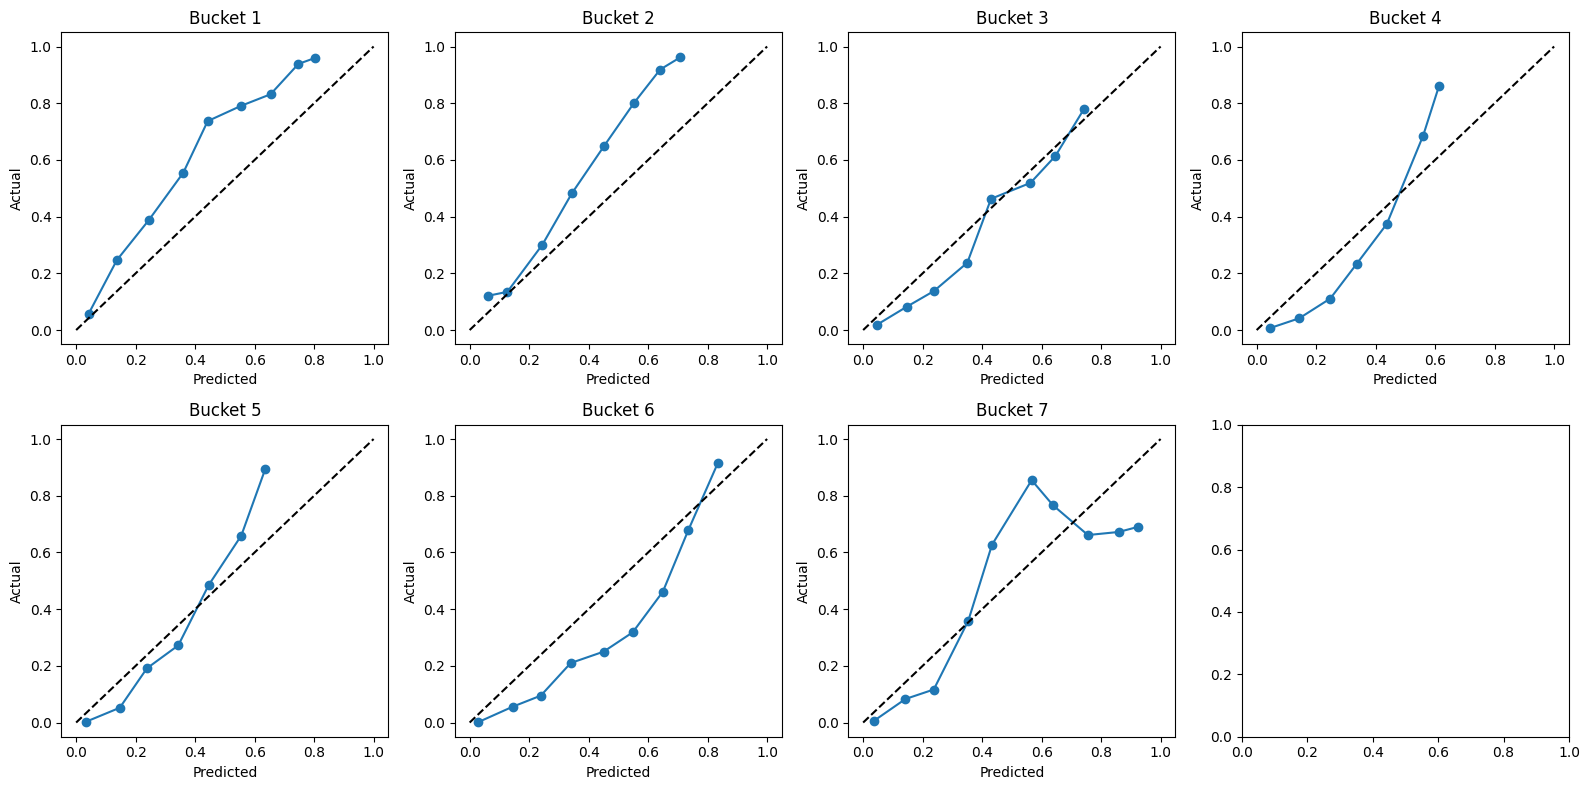

In [25]:
show_calibration_curves(base_probas, base_pipeline)

## 9.2 Simulate how the model would have performed at any point in time

In [26]:
def simulate_past_performance(pipeline):
    reference_dates = big_df["reference_date"].sort_values().unique()
    cutoffs = np.percentile(reference_dates.astype(int), [40, 50, 60, 70, 80])
    cutoffs = pd.to_datetime(cutoffs)

    scores = []
    for cutoff in cutoffs:
        train_df = big_df[big_df["reference_date"] <= cutoff]
        test_df = big_df[
            (big_df["reference_date"] > cutoff) &
            (big_df["reference_date"] <= cutoff + pd.Timedelta(weeks=6))
        ]

        if len(test_df) == 0:
            continue

        X_train, y_train = preprocess(train_df)
        X_test, y_test = preprocess(test_df)

        pipeline.fit(X_train, y_train)
        probas = pipeline.predict_proba(X_test)
        score = log_loss(y_test, probas, labels=pipeline.classes_)
        scores.append(score)
        print(f"Cutoff {cutoff.date()} -> log_loss: {score:.4f}")

    print(f"\nAverage: {np.mean(scores):.4f} (std: {np.std(scores):.4f})")

In [27]:
simulate_past_performance(base_pipeline)

Cutoff 2019-06-25 -> log_loss: 0.9441
Cutoff 2019-08-12 -> log_loss: 0.9807
Cutoff 2019-09-29 -> log_loss: 1.0475
Cutoff 2019-11-17 -> log_loss: 0.9219
Cutoff 2020-01-04 -> log_loss: 0.8856

Average: 0.9560 (std: 0.0552)


# 10. Tune the model

In [31]:
cutoff_date = big_df["reference_date"].quantile(0.8)
test_fold = np.where(big_df["reference_date"] <= cutoff_date, -1, 0)
ps = PredefinedSplit(test_fold)

X, y = preprocess(big_df)

## 10.1 GridSearchCV

In [29]:
# WARNING THIS CREATES 648 FOLDS SO IT TAKES A LONG TIME TO RUN LOCALLY AND MIGHT
# CRASH YOUR COMPUTER

# cutoff_date = big_df["reference_date"].quantile(0.8)
# test_fold = np.where(big_df["reference_date"] <= cutoff_date, -1, 0)
# ps = PredefinedSplit(test_fold)

# X, y = preprocess(big_df)

# param_grid = {
#     "classifier__n_estimators": [200, 300, 500],
#     "classifier__max_depth": [5, 8, 12, 15],
#     "classifier__min_samples_split": [10, 20, 30],
#     "classifier__min_samples_leaf": [5, 10, 20],
#     "classifier__max_features": ["sqrt", "log2", 0.3],
#     "classifier__class_weight": ["balanced", "balanced_subsample"],
# }

# grid_search = GridSearchCV(
#     base_pipeline,
#     param_grid,
#     cv=ps,
#     scoring="neg_log_loss",
#     n_jobs=-1,
#     verbose=1,
# )

# grid_search.fit(X, y)
# print(f"Best log_loss: {-grid_search.best_score_:.4f}")
# print(f"Best params: {grid_search.best_params_}")

# best_pipeline = grid_search.best_estimator_

## 10.2 RandomSearchCV

In [ ]:
param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 400, 500],
    "classifier__max_depth": [5, 8, 10, 12, 15, 20, None],
    "classifier__min_samples_split": randint(5, 40),
    "classifier__min_samples_leaf": randint(3, 30),
    "classifier__max_features": ["sqrt", "log2", 0.2, 0.3, 0.5],
    "classifier__class_weight": ["balanced", "balanced_subsample"],
}

random_search = RandomizedSearchCV(
    base_pipeline,
    param_distributions,
    n_iter=50,
    cv=ps,
    scoring="neg_log_loss",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

random_search.fit(X, y)
print(f"Best log_loss: {-random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")


Fitting 1 folds for each of 50 candidates, totalling 50 fits
